In [839]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt

In [840]:
annotate_path = '../data/annotation_v2/annotate_boxes/49.jpg'
orginal_path = '../data/annotation_v2/annotate_crop/49.jpg'

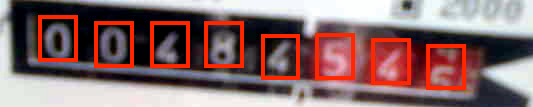

In [841]:
img = Image.open(annotate_path)
img

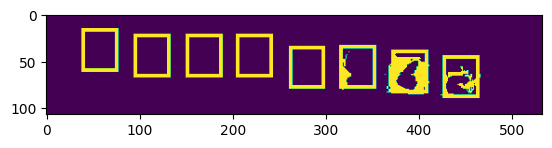

In [842]:
import numpy as np
image = cv2.imread(annotate_path)

# Convert image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define lower and upper bounds of red color in HSV color space
lower_red = np.array([0, 150, 150])
upper_red = np.array([15, 255, 255])
mask1 = cv2.inRange(hsv, lower_red, upper_red)

lower_red = np.array([170, 150, 150])
upper_red = np.array([180, 255, 255])
mask2 = cv2.inRange(hsv, lower_red, upper_red)

# Combine masks
mask = cv2.bitwise_or(mask1, mask2)

# Apply the mask to the original image
#mask = cv2.bitwise_and(image, image, mask=mask1)
plt.imshow(mask)
plt.show()

number of bounding boxes:  8


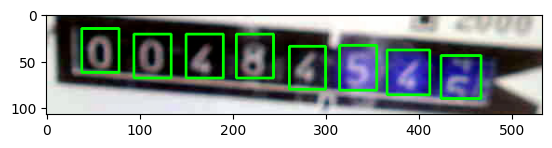

In [843]:
# Find contours
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

x = []
y = []
w = []
h = []
check = 0
if len(contours) > 0:
    for i in range(len(contours)):
        x1, y1, w1, h1 = cv2.boundingRect(contours[i])
        if cv2.contourArea(contours[i]) > 200:
            x.append(x1)
            y.append(y1)
            w.append(w1)
            h.append(h1)
            check += 1
print("number of bounding boxes: ", check)

image = cv2.imread(orginal_path)

for i in range(len(x)):
    cv2.rectangle(image, (x[i], y[i]), (x[i]+w[i], y[i]+h[i]), color = (0, 255, 0), thickness = 2)
plt.imshow(image)
plt.show()

In [844]:
import torch

torch.zeros(8, dtype=torch.int64)

tensor([0, 0, 0, 0, 0, 0, 0, 0])

In [845]:
# #rename all the files
# import glob
# import os
# for i, file in enumerate(glob.glob('../data/annotation_v2/temp1/*.jpg')):
#     os.rename(file, '../data/annotation_v2/temp1/' + str(i+78) + '.jpg')

In [846]:
# import numpy as np
# x = [1,2,3,4,5]
# np.array(x)+1

In [847]:
# import pandas as pd

# df = pd.read_csv('../data/annotation_v2/annotate.csv')

In [848]:
# # add file names to the dataframe
# import glob
# import os

# #add values to column fileid
# for i in range(74):
#     s = str(i+63)+'.jpg'
#     df.loc[len(df.index)] = [s, 0]

# #writing to csv file
# df.to_csv('../data/annotation_v2/annotate.csv', index=False)

In [849]:
# from IPython.display import display, HTML
  
# import pandas as pd
# from numpy.random import randint
  
# dict = {'Name':['Martha', 'Tim', 'Rob', 'Georgia'],
#         'Maths':[87, 91, 97, 95],
#         'Science':[83, 99, 84, 76]
#        }
  
# df = pd.DataFrame(dict)
  
# display(df)
  
# df.loc[len(df.index)] = ['Amy', 89, 93] 
  
# df